In [ ]:
import os, yaml, sys
import numpy as np
import matplotlib.pyplot as plt
import h5py
from IPython.display import clear_output
import random
from scipy.io import loadmat
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])
from useful_stuff.general_utils.utils import TimeSeries, compatible_TimeSeries_check, print_wise, get_lagplot
# from useful_stuff.general_utils.RSA import  dRSA
# from useful_stuff.general_utils.II import  dRSA, dynInformationImbalance
from useful_stuff.image_processing.computational_models import get_relevant_output_layers
from project_specific_utils.dataloader import load_concat_regressout_meg
from project_specific_utils.subsampling_lagged_comparisons import multivariate_lagged_comparisons
# from image_processing.gaze_dep_models import save_ANN_features


In [2]:
def plot_rsa(tot_rsa, neu_fs, max_lag, title=None, tick_step=20):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    # --- heatmap ---
    ax[0].imshow(tot_rsa)

    ticks = np.arange(-max_lag, max_lag + 1, tick_step)
    ticks_labels = np.round(ticks / neu_fs, 2)
    ticks += max_lag

    # --- lag plot ---
    lagplot = get_lagplot(tot_rsa, max_lag=max_lag)
    ax[1].plot(lagplot)

    ax[1].set_ylabel("dRSA similarity")
    ax[1].set_xlabel("lag [sec]")
    ax[1].set_xticks(ticks, ticks_labels)
    ax[1].axvline(max_lag, color="r", linestyle="--", linewidth=1)

    # --- 🔥 compute peak ---
    peak_idx = np.argmax(lagplot)
    peak_val = lagplot[peak_idx]
    peak_lag = (peak_idx - max_lag) / neu_fs  # convert to seconds

    # --- 🔥 textbox ---
    textstr = f"magnitude: {peak_val:.3f}\nlag: {peak_lag:.2f}s"
    ax[1].text(
        0.05, 0.95, textstr,
        transform=ax[1].transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
    )

    # --- labels ---
    ax[0].set_xlabel(f"Model time, length={tot_rsa.shape[1]/neu_fs}sec")
    ax[0].set_ylabel(f"Neural time, length={tot_rsa.shape[1]/neu_fs}sec")
    ax[0].set_xticks([])
    ax[0].set_yticks([])

    fig.suptitle(title, fontsize=20)
    plt.tight_layout()



In [3]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    sub_num = 3
    neu_fs = 100
    gaze_fs = 50
    sq_side = 384
    sensors_group = 'occ'
    model_name = "vit_l_16"
    pkg = "timm"
    pseudotrial_len = 600
    pseudotrials_n = 100
    full_model_name = "alexnet_features.4"
    n_model_components = 1000
    pooling = "all"
    PCs_to_regress_out = 50
    timepts_to_regress_out = (-100, 100)
    iterations_n = 10
    repetition = 0
    signal_metric = "correlation"
    model_metric = "correlation"
    regress_out_gaze = 'PCR' # or None or pointwise
    PCs_to_regress_out = 50
    analysis_type = "RSA"
cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, cfg.pkg)
mod_fs = config["movie_fs"]
model_len = [round(i*cfg.neu_fs/config["movie_fs"]) for i in config["model_len"]]

In [4]:
# """
# multivariate_lagged_comparisons
# Performs multivariate lagged comparisons (RSA or II) between neural and model data, and saves the results to disk.

# INPUT:
#     - paths: dict[str, str] -> project path dictionary
#     - n: TimeSeries -> neural signal (features x timepoints)
#     - analysis_type: str -> type of analysis ("RSA" or "II")
#     - sub_num: int -> subject number
#     - sensors_group: str -> MEG sensors group
#     - repetition: int -> repetition index (selects runs)
#     - full_model_name: str -> model/layer name
#     - iterations_n: int -> number of subsampling iterations
#     - pseudotrial_len: int -> length of pseudotrials (in timepoints)
#     - neu_fs: float -> sampling frequency of neural data
#     - signal_metric: str -> distance/similarity metric for neural data
#     - model_metric: str -> distance/similarity metric for model data
#     - pseudotrials_n: int -> number of pseudotrials per iteration
#     - sq_side: int -> spatial patch size used for model features
#     - regress_out_gaze: bool | str -> whether/how gaze regression is applied (used for naming)
#     - n_model_components: int -> number of PCA components for model features
#     - pooling: str (default="all") -> pooling type for model features
#     - rank: int (default=0) -> process rank for logging

# OUTPUT:
#     - None -> results are saved to disk as .mat files
#         - RSA: saves a single matrix (time x time)
#         - II: saves two matrices (A2B and B2A directions)
# """
# def multivariate_lagged_comparisons(paths, n, analysis_type, sub_num, sensors_group, repetition, full_model_name, iterations_n, pseudotrial_len, neu_fs, signal_metric, model_metric, pseudotrials_n, sq_side, regress_out_gaze, n_model_components, pooling="all", rank=0):
#     if cfg.analysis_type == "RSA":
#         p = [save_lagged_comparisons(paths, analysis_type, sub_num, sensors_group, i_rep, full_model_name, iterations_n, pseudotrial_len, neu_fs, signal_metric=signal_metric, model_metric=model_metric, pseudotrials_n=pseudotrials_n, sq_side=sq_side, regress_out_gaze=regress_out_gaze),]
#     elif cfg.analysis_type == "II":
#         p = []
#         pA2B = save_lagged_comparisons(paths, analysis_type+"A2B", sub_num, sensors_group, i_rep, full_model_name, iterations_n, pseudotrial_len, neu_fs, signal_metric=signal_metric, model_metric=model_metric, pseudotrials_n=pseudotrials_n, sq_side=sq_side, regress_out_gaze=regress_out_gaze)
#         p.append(pA2B)
#         pB2A = save_lagged_comparisons(paths, cfg.analysis_type+"B2A", sub_num, sensors_group, i_rep, full_model_name, iterations_n, pseudotrial_len, neu_fs, signal_metric=signal_metric, model_metric=model_metric, pseudotrials_n=pseudotrials_n, sq_side=sq_side, regress_out_gaze=regress_out_gaze)
#         p.append(pB2A)
#     if all(os.path.exists(path) for path in p):
#         print(f"{p[0]} already exists")
#         return None
#     m = load_concat_regressout_mod(paths, sub_num, save_ANN_features, full_model_name, repetition, mod_fs, neu_fs, *(sq_side, n_model_components, pooling), regress_out_gaze=False, gaze_dep=True, gaze_fs=50, rank=rank,)
#     tot_A2B, tot_B2A = subsampling_lagged_comparisons(n, m, pseudotrial_len, iterations_n, pseudotrials_n, model_len, subsampling_RSA, rank, *(signal_metric, model_metric))
#     if not cfg.regress_out_gaze:
#         cfg.regress_out_gaze = "0"
#     if cfg.analysis_type == "RSA":
#         savemat(p[0], {"RSA": tot_A2B})
#         print_wise(f"{full_model_name} saved at {p[0]}")
#     elif cfg.analysis_type == "II":
#         savemat(p[0], {"II": tot_A2B})
#         savemat(p[1], {"II": tot_B2A})
#         print_wise(f"{full_model_name} saved at {p[0]}")
#     return None

In [ ]:
from scipy.io import savemat
repetitions = [0,1]
rank = 0
for i_rep in repetitions:
    n = load_concat_regressout_meg(paths, cfg.sub_num, i_rep, cfg.sensors_group, cfg.neu_fs, cfg.gaze_fs, cfg.regress_out_gaze, cfg.PCs_to_regress_out, timepts_to_regress_out=cfg.timepts_to_regress_out, rank=0)
    for l in get_relevant_output_layers(cfg.model_name, pkg=cfg.pkg):
        full_model_name = f"{cfg.model_name}_{l}"
        multivariate_lagged_comparisons(paths, rank, full_model_name, n, cfg.analysis_type, cfg.sub_num, cfg.sensors_group, i_rep, cfg.iterations_n, cfg.pseudotrial_len, cfg.neu_fs, mod_fs, model_len, cfg.signal_metric, cfg.model_metric, cfg.pseudotrials_n, cfg.sq_side, cfg.regress_out_gaze, cfg.n_model_components)

19:41:28 - rank 0 Loading MEG signal: regress_out_gaze='PCR'
19:41:30 - rank 0 Shape runs [1 2 3]: [(41, 87379), (41, 86278), (41, 79071)]
19:41:30 - rank 0 Loading model vit_l_16_blocks.0.mlp.fc2: regress_out_gaze=False
19:41:30 - rank 0 vit_l_16_blocks.0.mlp.fc2: shape runs [1 2 3]: [(1000, 87379), (1000, 86278), (1000, 79071)]
19:41:30 - rank 0 starting iteration 0 of 9
19:41:40 - vit_l_16_blocks.0.mlp.fc2 saved at /Users/tizianocausin/1917_local/results/RSA_sub003_occ_rep0_vit_l_16_blocks.0.mlp.fc2_correlation-correlation_10iter_100pst_len_6s_384x384patch_regr_out_gaze_PCR.mat
19:41:40 - rank 0 Loading model vit_l_16_blocks.1.mlp.fc2: regress_out_gaze=False
19:41:41 - rank 0 vit_l_16_blocks.1.mlp.fc2: shape runs [1 2 3]: [(1000, 87379), (1000, 86278), (1000, 79071)]
19:41:41 - rank 0 starting iteration 0 of 9


KeyboardInterrupt: 

12 not found
13 not found
14 not found
15 not found
16 not found
17 not found
18 not found
19 not found
20 not found
21 not found
22 not found
23 not found


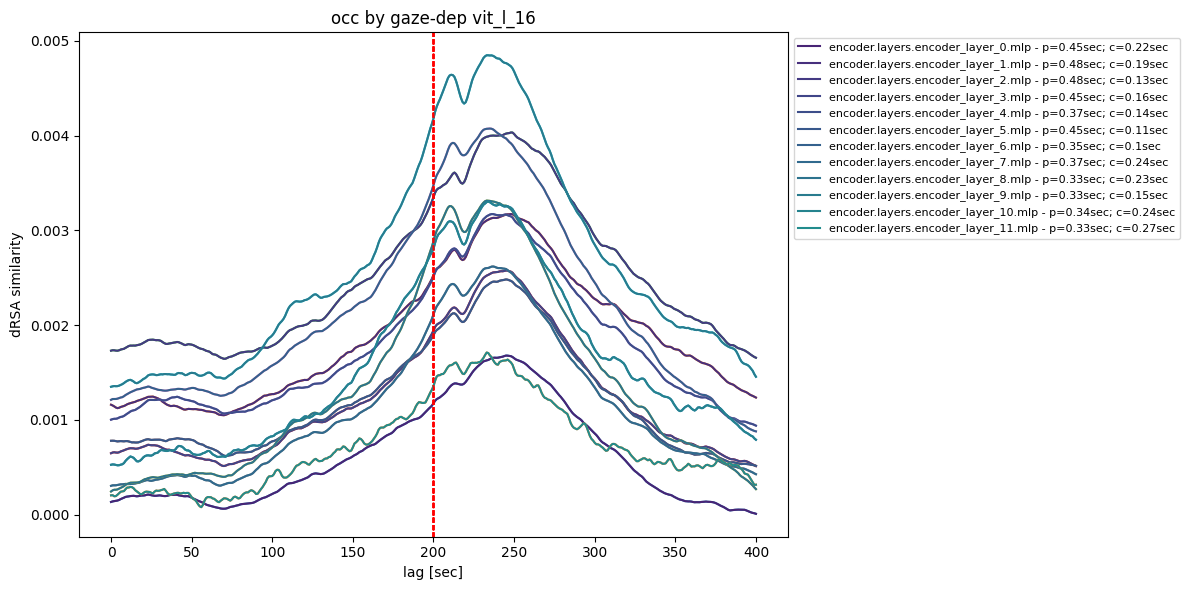

In [40]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
from useful_stuff.general_utils.plots import truncate_colormap
from useful_stuff.image_processing.computational_models import get_relevant_output_layers
layers = get_relevant_output_layers(cfg.model_name)
tick_step = 40
# --- choose colormap ---
cmap = truncate_colormap(plt.cm.viridis)  # or "plasma", "coolwarm", etc.
colors = cmap(np.linspace(0, 1, 24))
peaks = []
centroids = []
max_lag = 200
plt.figure(figsize=(12, 6))
for i in range(0,24):
    try:
        m = loadmat(f"/Users/tizianocausin/1917_local/results/RSA_sub003_occ_rep1_vit_l_16_blocks.{i}.mlp.fc2_correlation-correlation_1000iter_100pst_len_6s_384x384patch_regr_out_gaze_PCR.mat")
        lagplot = get_lagplot(m["RSA"], max_lag)
        plt.plot(lagplot)
        lagplots.append(lagplot)
        # --- compute peak ---
        peak_idx = np.argmax(lagplot)
        lags = np.arange(-max_lag, max_lag + 1)

        weights = lagplot.copy()
        weights[weights < 0] = 0  # optional but recommended

        centroid = np.sum(lags * weights) / np.sum(weights)
        centroid_lag = np.round(centroid / cfg.neu_fs, 2)
        peak_val = lagplot[peak_idx]
        peak_lag = (peak_idx - max_lag) / cfg.neu_fs  # convert to seconds
        peaks.append(peak_lag)
        centroids.append(centroid_lag)
        plt.plot(lagplot, label=f"{layers[i]} - p={peak_lag}sec; c={centroid_lag}sec", color=colors[i])
        plt.ylabel("dRSA similarity")
        plt.xlabel("lag [sec]")
        # plt.xticks(ticks, ticks_labels)
        plt.axvline(max_lag, color="r", linestyle="--", linewidth=1)
        

    except FileNotFoundError:
        print(f"{i} not found")
        pass
plt.title(f"{cfg.sensors_group} by gaze-dep {cfg.model_name}")#{cfg.sensors_group} sensors - regr out")
plt.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

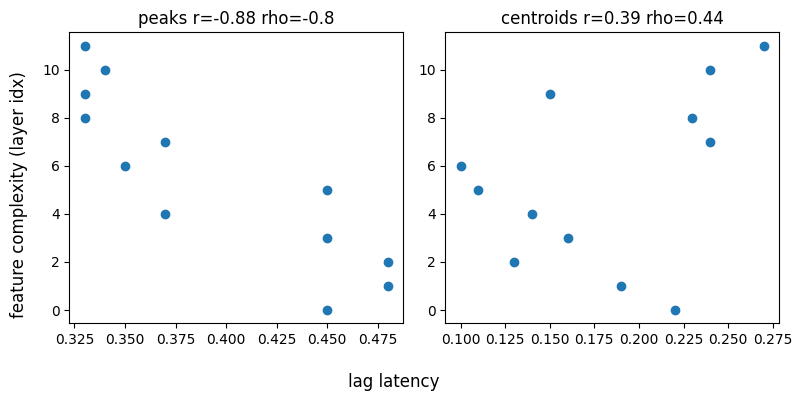

In [41]:
from useful_stuff.general_utils.utils import spearman
max_lag = 200
tick_step = 40
fig, ax = plt.subplots(1,2, figsize=(8, 4))
ax[0].scatter(np.array(peaks), np.arange(len(peaks)))
rho = np.round(spearman(np.arange(len(peaks)), np.array(peaks)),2)
r = round(np.corrcoef(np.arange(len(peaks)), np.array(peaks))[0,1],2)
ax[0].set_title(f"peaks r={r} rho={rho}")
ax[1].scatter(centroids, np.arange(len(centroids)));
rho = np.round(spearman(np.arange(len(peaks)), np.array(centroids)), 2)
r = round(np.corrcoef(np.arange(len(centroids)), np.array(centroids))[0,1],2)
ax[1].set_title(f"centroids r={r} rho={rho}")
fig.supxlabel("lag latency")
fig.supylabel("feature complexity (layer idx)")
fig.tight_layout()

In [ ]:
full_model_name = "alexnet_features.0"
p = save_lagged_comparisons(paths, cfg.analysis_type+"A2B", cfg.sub_num, cfg.sensors_group, full_model_name, cfg.iterations_n, cfg.pseudotrial_len, cfg.neu_fs, signal_metric=cfg.signal_metric, model_metric=cfg.signal_metric, pseudotrials_n= cfg.pseudotrials_n, sq_side=cfg.sq_side, regress_out_gaze=cfg.regress_out_gaze)
print(p)

/Users/tizianocausin/1917_local/results/IIA2B_sub003_occ_alexnet_features.0_cosine_cnt-cosine_cnt_100iter_50pst_len_6s_384x384patch_regr_out_gaze_PCR.mat


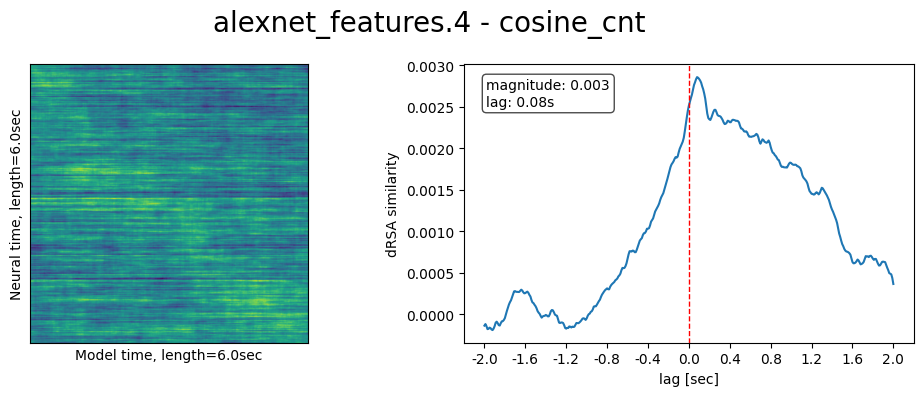

In [ ]:
/Users/tizianocausin/1917_local/results/RSA_sub003_occ_rep0_alexnet_features.7_correlation-correlation_1000iter_100pst_len_6s_384x384patch_regr_out_gaze_PCR.mat
plot_rsa(tot_rsa, cfg.neu_fs, cfg.max_lag, f"{cfg.full_model_name} - {cfg.RDM_metric}", tick_step=40)

In [ ]:
tot_II_A2B, tot_II_B2A = subsampling_lagged_comparisons(neu, mod, cfg.time_points, cfg.iterations_n-80, cfg.pseudotrials_n, len_mod, subsampling_II, 0, *(cfg.RDM_metric, cfg.RDM_metric),**{"k": 20})

19:32:48 - rank 0 starting iteration 0 of 19
19:33:32 - rank 0 starting iteration 10 of 19


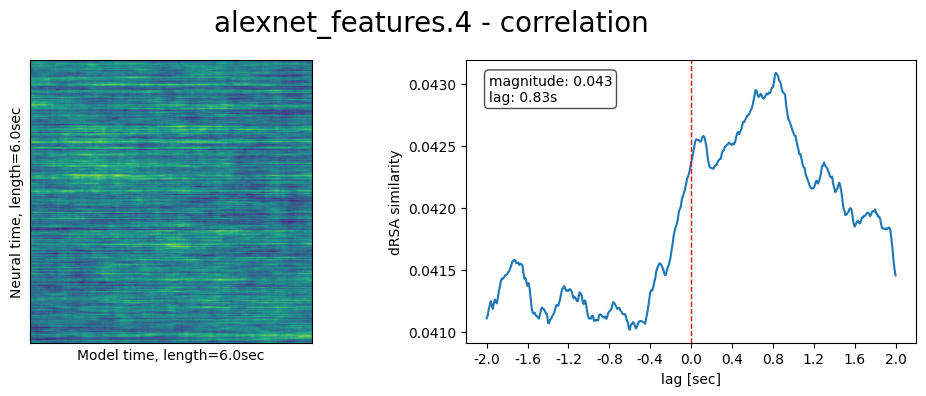

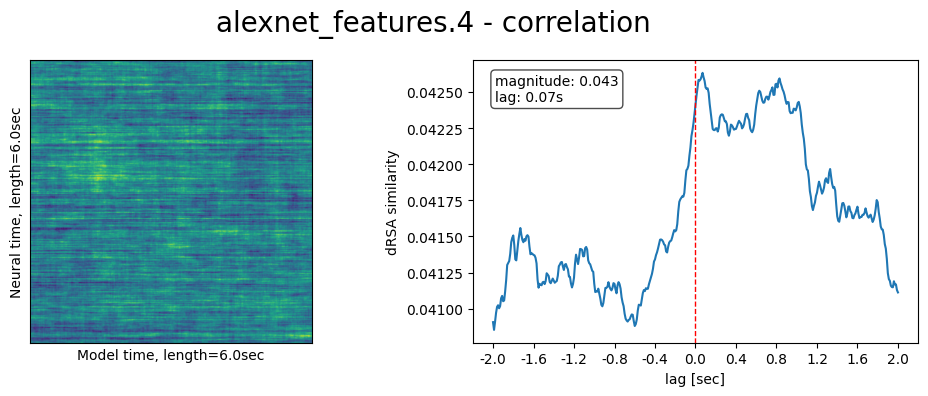

In [ ]:
plot_rsa(1-tot_II_A2B, cfg.neu_fs, cfg.max_lag, f"{cfg.full_model_name} - {cfg.RDM_metric}", tick_step=40)
plot_rsa(1-tot_II_B2A, cfg.neu_fs, cfg.max_lag, f"{cfg.full_model_name} - {cfg.RDM_metric}", tick_step=40) #TODO check if the dynII is correct in its timecourse...

In [ ]:
print(cfg.pseudotrials_n)

50


In [ ]:
r = subsampling_lagged_comparisons('encoding', neu, mod, cfg.time_points, cfg.iterations_n - 99, cfg.pseudotrials_n, subsampling_encoding, 0, *('ridge', 'kf', 5),**{"score_type": "corr", "n_splits": 2, }) 

12:40:25 - rank 0 starting iteration 0 of 0
(1, 11)


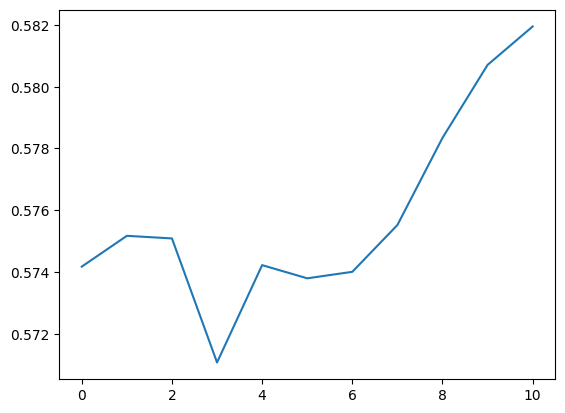

In [ ]:
plt.plot(r.T);